In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 8** - maximizing 8D black-box function

- Here we are optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown.

- **Objective** - find the parameter combination that maximises the function’s output, such as _performance_, _efficiency_ or _validation accuracy_.
  - Because the function is high-dimensional and likely complex, global optimisation is hard, so **identifying strong local maxima** is often a practical strategy.

- **For example**, imagine you’re tuning an ML model with eight hyperparameters:
  - learning rate
  - batch size
  - number of layers
  - dropout rate
  - regularisation strength
  - activation function (numerically encoded)
  - optimiser type (encoded)
  - initial weight range.

Each input set returns a single validation accuracy score between 0 and 1.

- **Input** - 8D (40,8)
- **Output** - 8D (40,)
- **Goal** - maximise this score


In [2]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_8\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_8\initial_outputs.npy')

In [3]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.007838, 0.337307, 0.164679, 0.407388, 0.632409, 0.551169, 0.306982, 0.502300], dtype=np.float64)
Y_w1_new_point = np.array([9.8375654737465], dtype=np.float64)

# Append the new data points
X_updated = np.vstack((X, X_w1_new_point))
Y_updated = np.append(Y, Y_w1_new_point)

# Save the updated arrays
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_8\initial_inputs.npy', X_updated)
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_8\initial_outputs.npy', Y_updated)

In [4]:
print("Updated Inputs (X) - Function 8: ", X_updated)
print("Updated Outputs (Y) - Function 8: ", Y_updated)

Updated Inputs (X) - Function 8:  [[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0

### **Interpretation of output and next steps**


- In an 8D space, "global optimisation is hard, so identifying strong local maxima is often a practical strategy".

- My current result of 9.838 indicates that I might be close to a strong local pocket.
  - I think my next step is to determine if this is the best local peak or if a better one exists elsewhere in the complex 8D landscape.

- To do this I think I want to continue exploration using the matern kernel and the Expected improvement surrogate model in order to hopeful find another strong point.


### **Bayesian Optimisation** - Strategic Approach using Expected Improvements (EI)

- I am using Tikhonov regularization for matrix stability.
  - Since validation accuracy is generally consistent for a fixed set of hyperparameters, we keep noise low to ensure high fidelity to the 40 data points while maintaining numerical stability.

- From some basic research I found out that the Matérn 5/2 kernel is the industry standard for high-dimensional ML tuning because it captures "discrete cliffs" and sharp changes better than the over-smooth RBF kernel.

- I would also like to use the [0.5]\*6 length scale which makes us question each hyperparameter individually to assess the impact of each on the overall function.


In [5]:
kernel = Matern(length_scale=[0.5]*8, nu=2.5)

model = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=1e-5,
    n_restarts_optimizer=40, 
    normalize_y=True,
    random_state=42
)

model.fit(X_updated, Y_updated)

c:\Users\Pratham\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(alpha=1e-05,
                         kernel=Matern(length_scale=[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], nu=2.5),
                         n_restarts_optimizer=40, normalize_y=True,
                         random_state=42)

### **Acquisition Function** - Expected Improvement (EI)

- Unlike other functions (like UCB), standard EI does not require tuning internal hyperparameters, making it more robust when data is sparse

- I have decided to use numerically stable formulation (LogEI) to compute the logarithm of improvement directly.
  - This allows the optimizer to "see" and target improvements which are small that would otherwise be invisible, preventing the search from reverting to random sampling.

- Additionally, we evaluate 500,000 points to ensure coverage of the 8D volume.


In [6]:
def expected_improvement(X_grid, model, y_max, xi=0.01):
    mu, sigma = model.predict(X_grid, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore', invalid = 'ignore'):
        imp = mu - y_max - xi
        Z = imp / (sigma + 1e-9)
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    return ei.ravel()

x_grid = np.random.uniform(0, 1, size=(500000, 8))
y_max = np.max(Y_updated)
ei_values = expected_improvement(x_grid, model, y_max)

best_idx = np.argmax(ei_values)
next_query = x_grid[best_idx]

print(f"Next Submission for Function 8 - Bayesian Optimisation (EI): "
        f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}-{next_query[5]:.6f}-{next_query[6]:.6f}-{next_query[7]:.6f}")

Next Submission for Function 8 - Bayesian Optimisation (EI): 0.117464-0.226763-0.160734-0.103849-0.998846-0.763666-0.087753-0.474624


### **Visualisation of the progress for different inputs**


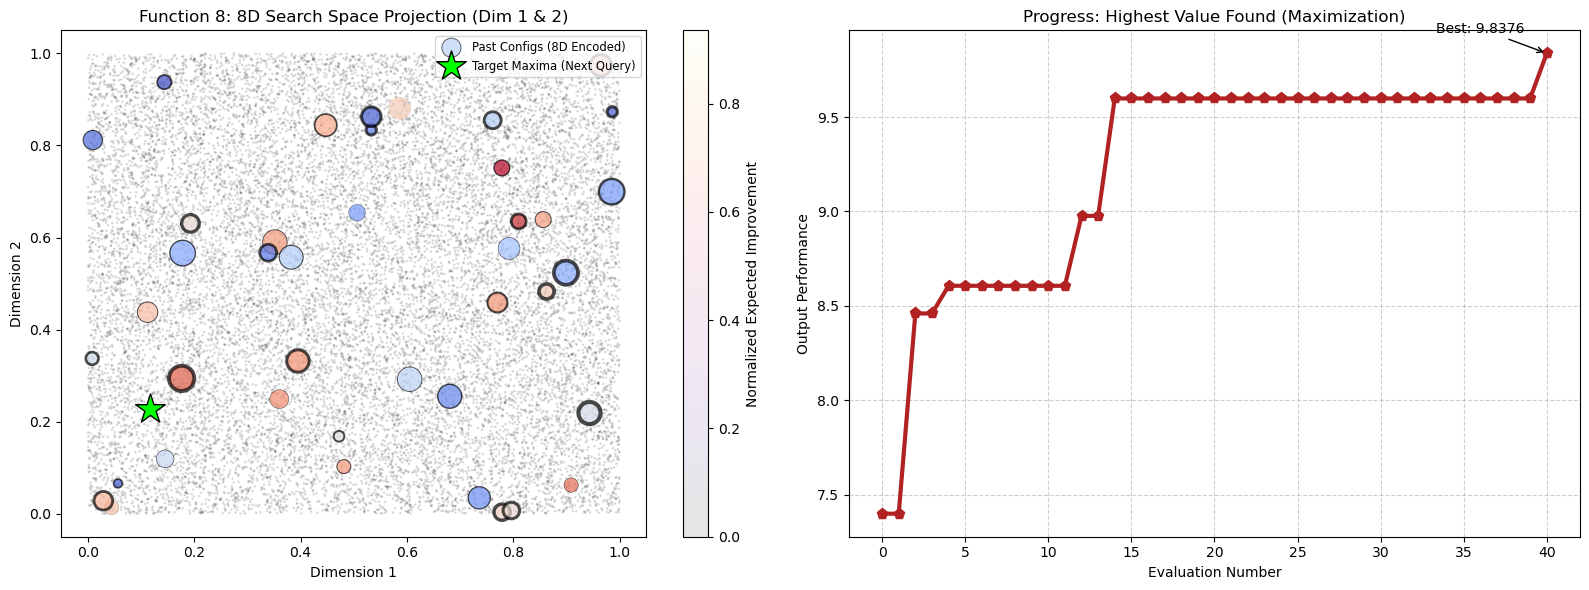

In [7]:
running_max = np.maximum.accumulate(Y_updated)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 8D Projection Parameters
x3_scaled = (X_updated[:, 2] - np.min(X_updated[:, 2])) / (np.ptp(X_updated[:, 2]) + 1e-12)
past_sizes = 40 + (300 * x3_scaled) 

# 3. The Search Map: 8D Projected View
acq_norm = (ei_values - np.nanmin(ei_values)) / (np.nanmax(ei_values) - np.nanmin(ei_values) + 1e-12)

# High-density scatter for the background (sampled for performance)
sample_idx = np.random.choice(len(x_grid), 20000, replace=False)
sc = ax1.scatter(x_grid[sample_idx, 0], x_grid[sample_idx, 1], c=acq_norm[sample_idx], 
                cmap='magma', s=1, alpha=0.1)
cbar = plt.colorbar(sc, ax=ax1, label='Normalized Expected Improvement')

# Past Samples: Encoded with multi-dimensional attributes
past_sc = ax1.scatter(X_updated[:, 0], X_updated[:, 1], 
                      c=X_updated[:, 3], 
                      cmap='coolwarm', 
                      s=past_sizes, 
                      edgecolors='black', 
                      linewidth=X_updated[:, 4] * 3, 
                      alpha=0.7, 
                      label='Past Configs (8D Encoded)')

# Next Query: The potential global maximum identified by the model
ax1.scatter(next_query[0], next_query[1], c='lime', marker='*', s=500, 
            edgecolors='black', label='Target Maxima (Next Query)')

ax1.set_title('Function 8: 8D Search Space Projection (Dim 1 & 2)')
ax1.set_xlabel('Dimension 1')
ax1.set_ylabel('Dimension 2')
ax1.legend(loc='upper right', fontsize='small')

# Progress Plot: Finding Strong Local Maxima
ax2.plot(running_max, color='firebrick', linewidth=3, marker='p', markersize=8)
ax2.set_title('Progress: Highest Value Found (Maximization)')
ax2.set_xlabel('Evaluation Number')
ax2.set_ylabel('Output Performance')
ax2.grid(True, linestyle='--', alpha=0.6)

# Annotate the current best found
ax2.annotate(f'Best: {np.max(Y_updated):.4f}', 
             xy=(len(Y_updated)-1, np.max(Y_updated)), 
             xytext=(-80, 15), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()